# Proyecto 2
## Agile Community Rules Classification
### Análisis Exploratorio


Intregantes:
- André pivaral  
- Belén Monterroso 
- Melisa Mendizabal 
- Renato Rojas 


# Descripción de los datos y limpieza de datos
### Librerías necesarias

In [1]:
import os
import re
import string
import warnings
 
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
 
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
 
from wordcloud import WordCloud
from langdetect import detect, LangDetectException
 
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

### Set de datos

In [2]:
import pandas as pd

train = pd.read_csv('Datos/train.csv')
test = pd.read_csv('Datos/test.csv')

print(test.head())

   row_id                                               body  \
0    2029  NEW RAP GROUP 17. CHECK US OUT https://soundcl...   
1    2030  Make your life comfortable. Get up to 15% Disc...   
2    2031  Kickin' ass and selling underwear!\nJust made ...   
3    2032   watch  hooters  best  therein  http://clickan...   
4    2033   bitches  for free  at this point  show all  h...   

                                                rule        subreddit  \
0  No Advertising: Spam, referral links, unsolici...      hiphopheads   
1  No legal advice: Do not offer or request legal...        AskReddit   
2  No Advertising: Spam, referral links, unsolici...         gonewild   
3  No Advertising: Spam, referral links, unsolici...  personalfinance   
4  No Advertising: Spam, referral links, unsolici...   Showerthoughts   

                                  positive_example_1  \
0  Hey, guys, just wanted to drop in and invite y...   
1  Get a lawyer and get the security camera foota...   
2  Good 

## Dimensiones de los data sets y variables

In [3]:
print(f"train.csv: {train.shape[0]} filas x {train.shape[1]} columnas")
print(f"test.csv : {test.shape[0]} filas x {test.shape[1]} columnas")
print("\nColumnas train:", list(train.columns))
print("Columnas test :", list(test.columns))

train.csv: 2029 filas x 9 columnas
test.csv : 10 filas x 8 columnas

Columnas train: ['row_id', 'body', 'rule', 'subreddit', 'positive_example_1', 'positive_example_2', 'negative_example_1', 'negative_example_2', 'rule_violation']
Columnas test : ['row_id', 'body', 'rule', 'subreddit', 'positive_example_1', 'positive_example_2', 'negative_example_1', 'negative_example_2']


## Separación de la variable objetivo en test

In [4]:
TARGET = "rule_violation"
assert TARGET in train.columns and TARGET not in test.columns, (
    "Se esperaba que 'rule_violation' esté solo en train (es el target)."
)

## Descripción de las variables
- row_id: numérica discreta (identificador único, no  predictiva)
- body: texto (comentario de Reddit a clasificar)
- rule: categórica (texto de la regla de moderación)
- subreddit: categórica (comunidad de origen)
- positive_example_1/2: texto (ejemplos que sí violan la regla, dados como contexto)
- negative_example_1/2: texto (ejemplos que no violan la regla, dados como contexto)
- rule_violation: categórica binaria (TARGET): 0 = no viola, 1 = viola

### Tipos de variables

In [5]:
print(train.dtypes)

row_id                 int64
body                  object
rule                  object
subreddit             object
positive_example_1    object
positive_example_2    object
negative_example_1    object
negative_example_2    object
rule_violation         int64
dtype: object


## Valores faltantes o presencia de datos nulos
Al no encontrar valores nulos en ninguno de los dos datasets no se aplicará ninguna estrategia de imputación. Esto indica que el dataset presenta un limpieza previa por los organizadores del reto previo a su publicación

In [6]:
nulls_train = train.isnull().sum()
nulls_test = test.isnull().sum()
print("Nulos por columna en train:")
print(nulls_train)
print("\nNulos por columna en test:")
print(nulls_test)
 
total_nulls = nulls_train.sum() + nulls_test.sum()
if total_nulls == 0:
    print(
        "No hay valores nulos."
    )
else:
    print(
        "Sí se encontraron nulos"
    )

Nulos por columna en train:
row_id                0
body                  0
rule                  0
subreddit             0
positive_example_1    0
positive_example_2    0
negative_example_1    0
negative_example_2    0
rule_violation        0
dtype: int64

Nulos por columna en test:
row_id                0
body                  0
rule                  0
subreddit             0
positive_example_1    0
positive_example_2    0
negative_example_1    0
negative_example_2    0
dtype: int64
No hay valores nulos.


## Valores duplicados

### Duplicados exactos

In [7]:
dup_full_train = train.duplicated().sum()
dup_full_test = test.duplicated().sum()
print(f"Filas 100% duplicadas en train: {dup_full_train}")
print(f"Filas 100% duplicadas en test : {dup_full_test}")

Filas 100% duplicadas en train: 0
Filas 100% duplicadas en test : 0


### Duplicados de 'body' 
El mismo comentario aparece varias veces, pero posiblemente evaluado contra reglas/subreddits distintos

In [8]:
dup_body_mask_train = train.duplicated(subset=["body"], keep=False)
n_dup_body_train = train.loc[dup_body_mask_train, "body"].nunique()
print(f"\nComentarios ('body') que se repiten al menos 2 veces en train: "
      f"{n_dup_body_train} textos distintos, "
      f"{dup_body_mask_train.sum()} filas involucradas.")


Comentarios ('body') que se repiten al menos 2 veces en train: 57 textos distintos, 217 filas involucradas.


### Validación de duplicados y tratamiento

NO eliminamos los 'body' duplicados. La unidad de análisis de este problema no es el comentario por sí solo, sino el par (comentario, regla). Un mismo comentario puede violar la regla de 'No Advertising' en un subreddit y no violar la regla de 'No legal advice' en otro contexto, por lo que cada fila aporta información distinta al modelo. Sí eliminamos, en cambio, duplicados exactos de FILA COMPLETA (idéntica en todas las columnas), ya que esos sí son redundancia pura.

In [9]:
dup_groups = (
    train[dup_body_mask_train]
    .groupby("body")[TARGET]
    .nunique()
)
n_consistent = (dup_groups == 1).sum()
n_inconsistent = (dup_groups > 1).sum()
print(f"  - Grupos de duplicados con etiqueta CONSISTENTE: {n_consistent}")
print(f"  - Grupos de duplicados con etiqueta INCONSISTENTE (mismo texto, "
      f"distinta regla -> distinto veredicto): {n_inconsistent}")
 
print("")
before = len(train)
train = train.drop_duplicates().reset_index(drop=True)
after = len(train)
print(f"Filas eliminadas por duplicado exacto de fila completa: {before - after}")
 
before_t = len(test)
test = test.drop_duplicates().reset_index(drop=True)
after_t = len(test)
print(f"Filas eliminadas por duplicado exacto en test: {before_t - after_t}")

  - Grupos de duplicados con etiqueta CONSISTENTE: 43
  - Grupos de duplicados con etiqueta INCONSISTENTE (mismo texto, distinta regla -> distinto veredicto): 14

Filas eliminadas por duplicado exacto de fila completa: 0
Filas eliminadas por duplicado exacto en test: 0


## LIMPIEZA Y NORMALIZACIÓN DE TEXTO

In [10]:
URL_REGEX = re.compile(r"(https?://\S+|www\.\S+)")
MD_LINK_REGEX = re.compile(r"\[([^\]]*)\]\((https?://[^\)]+)\)")  # [texto](url)
MD_BOLD_ITALIC_REGEX = re.compile(r"(\*\*|\*|__|_)")
MD_QUOTE_REGEX = re.compile(r"^>.*$", flags=re.MULTILINE)
EMOJI_REGEX = re.compile(
    "["
    "\U0001F300-\U0001FAFF"  # símbolos, emoticones, transporte, etc.
    "\U00002600-\U000027BF"  # símbolos varios / dingbats
    "\U0001F1E6-\U0001F1FF"  # banderas
    "]+",
    flags=re.UNICODE,
)
NON_ALPHA_REGEX = re.compile(r"[^a-z\s]")

### Cantidad de urls

In [11]:
def count_urls(text):
    raw_urls = len(URL_REGEX.findall(text))
    md_urls = len(MD_LINK_REGEX.findall(text))
    return raw_urls + md_urls

### Cantidad de signos de exclamación

In [12]:
def count_exclamations(text):
    return text.count("!")

### Cantidad de emojis

In [13]:
def count_emojis(text):
    return len(EMOJI_REGEX.findall(text))


### Proporción de mayúsculas
Se calcula sobre el texto original, antes de convertirlo a minúsculas, porque escribir en mayúsculas ('GRITAR') es una señal típica de contenido promocional o spam que se perdería si primero se normaliza el texto.

In [14]:
def caps_ratio(text):
    letters = [c for c in text if c.isalpha()]
    if not letters:
        return 0.0
    upper = sum(1 for c in letters if c.isupper())
    return upper / len(letters)

## Limpieza del texto
El orden de las operaciones importa: primero se extraen las URLs y el formato markdown de Reddit (negrita, cursiva, citas), después se pasa todo a minúsculas y por último se eliminan emojis y caracteres no alfabéticos. Así se evita que, por ejemplo, una URL en mayúsculas quede a medio limpiar.

In [15]:
def clean_text(text):
    text = str(text)
    text = MD_LINK_REGEX.sub(" ", text)
    text = URL_REGEX.sub(" ", text)
    text = MD_QUOTE_REGEX.sub(" ", text)
    text = MD_BOLD_ITALIC_REGEX.sub(" ", text)
    text = text.lower()
    text = EMOJI_REGEX.sub(" ", text)
    text = NON_ALPHA_REGEX.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

### Tokenización, eliminación de stopwords y lematización
Se guarda como texto unido por espacios para poder alimentar directamente un vectorizador TF-IDF más adelante en el modelado.

In [16]:
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

STOPWORDS_EN = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

def tokenize_lemmatize(text):
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS_EN and len(t) > 1]
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    return " ".join(tokens)

### Palabras clave asociadas a cada regla
Se define un pequeño diccionario de palabras típicas de spam/publicidad y de asesoría legal, para usarlas como variables binarias en el EDA.

In [17]:
SPAM_KEYWORDS = ["click here", "discount", "free", "subscribe", "buy now",
                 "sale", "offer", "% off", "limited time", "download",
                 "stream", "promo", "referral"]

LEGAL_KEYWORDS = ["lawyer", "sue", "court", "legal", "attorney",
                  "lawsuit", "law ", "illegal", "sued"]

## Aplicación de la limpieza y generación de variables derivadas
Se aplica exactamente la misma función a train y a test, para que el modelo reciba en test las mismas columnas y bajo la misma lógica con la que fue entrenado en train. La única columna que no se puede calcular en test es la que depende del target (rule_violation), porque test no la trae.

In [18]:
def enrich_dataframe(df):
    df["char_length"] = df["body"].str.len()
    df["word_count"] = df["body"].str.split().apply(len)
    df["url_count"] = df["body"].apply(count_urls)
    df["exclamation_count"] = df["body"].apply(count_exclamations)
    df["emoji_count"] = df["body"].apply(count_emojis)
    df["caps_ratio"] = df["body"].apply(caps_ratio)
    df["has_url"] = (df["url_count"] > 0).astype(int)

    body_lower = df["body"].str.lower()
    df["has_spam_keyword"] = body_lower.apply(
        lambda t: int(any(k in t for k in SPAM_KEYWORDS))
    )
    df["has_legal_keyword"] = body_lower.apply(
        lambda t: int(any(k in t for k in LEGAL_KEYWORDS))
    )

    df["body_clean"] = df["body"].apply(clean_text)
    df["body_lemmatized"] = df["body_clean"].apply(tokenize_lemmatize)

    return df

train = enrich_dataframe(train)
test = enrich_dataframe(test)

### Ejemplo antes y después de la limpieza

In [19]:
print("ANTES  :", train.loc[0, "body"][:200])
print("DESPUÉS:", train.loc[0, "body_clean"][:200])
print("LEMATIZADO:", train.loc[0, "body_lemmatized"][:200])
print('')
print("ANTES  :", train.loc[18, "body"][:300])
print("DESPUÉS:", train.loc[18, "body_clean"][:300])
print("LEMATIZADO:", train.loc[18, "body_lemmatized"][:300])

ANTES  : Banks don't want you to know this! Click here to know more!
DESPUÉS: banks don t want you to know this click here to know more
LEMATIZADO: bank want know click know

ANTES  : Highlights and Interviews: http://swish.io/game/nba/nba-lakers-raptors-20161202

Hi Reddit Community! We're a sports consumption startup, and we'll be posting highlights from all NBA games within 24 hours of their conclusion. You can go to our website swish.io or download our app to get real time hi
DESPUÉS: highlights and interviews hi reddit community we re a sports consumption startup and we ll be posting highlights from all nba games within hours of their conclusion you can go to our website swish io or download our app to get real time highlights for your favorite games if you like anything we re d
LEMATIZADO: highlight interview hi reddit community sport consumption startup posting highlight nba game within hour conclusion go website swish io download app get real time highlight favorite game like a

## Verificación de idioma
Se confirma el supuesto de que el corpus está mayormente en inglés. Un detector automático puede fallar en textos muy cortos o con muchos símbolos/URLs, así que un pequeño porcentaje distinto de 'en' es esperable y no implica traducir ni eliminar esas filas.

In [20]:
def safe_detect(text):
    text = text.strip()
    if len(text) < 3:
        return "unknown"
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

train["lang"] = train["body"].apply(safe_detect)
test["lang"] = test["body"].apply(safe_detect)

print("Distribución de idiomas en train:")
print(train["lang"].value_counts(normalize=True).head(10))
print("\nDistribución de idiomas en test:")
print(test["lang"].value_counts(normalize=True).head(10))

Distribución de idiomas en train:
lang
en    0.946279
de    0.013800
da    0.004436
sv    0.003943
fr    0.002957
af    0.002957
nl    0.002464
vi    0.001971
cy    0.001971
es    0.001971
Name: proportion, dtype: float64

Distribución de idiomas en test:
lang
en    0.9
de    0.1
Name: proportion, dtype: float64


# Análisis exploratorio de los datos

## Resumen de variables numéricas
Se describen las variables numéricas derivadas del texto, tanto de forma global como separadas por clase (rule_violation), para ver si hay diferencias entre comentarios que violan la regla y los que no.

In [21]:
numeric_cols = ["char_length", "word_count", "url_count",
                "exclamation_count", "emoji_count", "caps_ratio"]

print(train[numeric_cols].describe().T)

                    count        mean         std   min        25%  \
char_length        2029.0  176.842780  113.623910  51.0  87.000000   
word_count         2029.0   27.963036   21.230214   1.0  11.000000   
url_count          2029.0    0.647610    1.059158   0.0   0.000000   
exclamation_count  2029.0    0.255298    0.765296   0.0   0.000000   
emoji_count        2029.0    0.007886    0.133001   0.0   0.000000   
caps_ratio         2029.0    0.065141    0.101533   0.0   0.018519   

                          50%         75%    max  
char_length        138.000000  238.000000  499.0  
word_count          22.000000   39.000000   97.0  
url_count            0.000000    1.000000   10.0  
exclamation_count    0.000000    0.000000    9.0  
emoji_count          0.000000    0.000000    3.0  
caps_ratio           0.033557    0.071429    1.0  


In [22]:
print(train.groupby(TARGET)[numeric_cols].mean().T)

rule_violation              0           1
char_length        157.588176  195.481086
word_count          23.134269   32.637245
url_count            0.875752    0.426770
exclamation_count    0.228457    0.281280
emoji_count          0.007014    0.008729
caps_ratio           0.074922    0.055672


## Tablas de frecuencia de variables categóricas

### Frecuencia de la variable objetivo (rule_violation)

In [23]:
print(train[TARGET].value_counts())
print(train[TARGET].value_counts(normalize=True).round(3))

rule_violation
1    1031
0     998
Name: count, dtype: int64
rule_violation
1    0.508
0    0.492
Name: proportion, dtype: float64


### Frecuencia de la variable 'rule'

In [24]:
print(train["rule"].value_counts())

rule
No legal advice: Do not offer or request legal advice.                                                     1017
No Advertising: Spam, referral links, unsolicited advertising, and promotional content are not allowed.    1012
Name: count, dtype: int64


### Top 15 subreddits más frecuentes

In [25]:
print(train["subreddit"].value_counts().head(15))
print(f"\nTotal de subreddits distintos en train: {train['subreddit'].nunique()}")

subreddit
legaladvice        213
AskReddit          152
soccerstreams      139
personalfinance    125
relationships      106
The_Donald          94
TwoXChromosomes     87
news                65
movies              56
videos              50
politics            49
worldnews           49
sex                 42
science             32
pics                30
Name: count, dtype: int64

Total de subreddits distintos en train: 100


### Proporción de indicadores binarios (has_url, has_spam_keyword, has_legal_keyword)

In [26]:
for col in ["has_url", "has_spam_keyword", "has_legal_keyword"]:
    print(f"{col}:")
    print(train[col].value_counts(normalize=True).round(3).to_dict())

has_url:
{0: 0.57, 1: 0.43}
has_spam_keyword:
{0: 0.782, 1: 0.218}
has_legal_keyword:
{0: 0.815, 1: 0.185}


## Cruce de variables
Se cruza el target con las variables categóricas y numéricas más relevantes para identificar qué elementos se asocian con la violación de una regla.

### Tasa de violación por regla

In [27]:
print(train.groupby("rule")[TARGET].mean().round(3))

rule
No Advertising: Spam, referral links, unsolicited advertising, and promotional content are not allowed.    0.433
No legal advice: Do not offer or request legal advice.                                                     0.583
Name: rule_violation, dtype: float64


### Tasa de violación según presencia de URL y palabras clave

In [28]:
print("Por has_url:")
print(train.groupby("has_url")[TARGET].mean().round(3))

print("\nPor has_spam_keyword:")
print(train.groupby("has_spam_keyword")[TARGET].mean().round(3))

print("\nPor has_legal_keyword:")
print(train.groupby("has_legal_keyword")[TARGET].mean().round(3))

Por has_url:
has_url
0    0.567
1    0.430
Name: rule_violation, dtype: float64

Por has_spam_keyword:
has_spam_keyword
0    0.537
1    0.405
Name: rule_violation, dtype: float64

Por has_legal_keyword:
has_legal_keyword
0    0.428
1    0.859
Name: rule_violation, dtype: float64


### Tasa de violación por subreddit (top 15 más frecuentes)

In [29]:
top_subs = train["subreddit"].value_counts().head(15).index
print(
    train[train["subreddit"].isin(top_subs)]
    .groupby("subreddit")[TARGET]
    .mean()
    .sort_values(ascending=False)
    .round(3)
)

subreddit
sex                0.810
legaladvice        0.789
personalfinance    0.696
relationships      0.613
politics           0.592
news               0.585
pics               0.567
The_Donald         0.553
AskReddit          0.480
TwoXChromosomes    0.460
videos             0.400
worldnews          0.388
movies             0.375
science            0.375
soccerstreams      0.029
Name: rule_violation, dtype: float64


### Correlación entre variables numéricas y el target

In [30]:
corr_matrix = train[numeric_cols + [TARGET]].corr()
print(corr_matrix[TARGET].sort_values(ascending=False).round(3))

rule_violation       1.000
word_count           0.224
char_length          0.167
exclamation_count    0.035
emoji_count          0.006
caps_ratio          -0.095
url_count           -0.212
Name: rule_violation, dtype: float64


## Gráficos exploratorios


In [31]:
FIG_DIR = "figuras"
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=150, bbox_inches="tight")

### Distribución de la longitud del comentario por clase

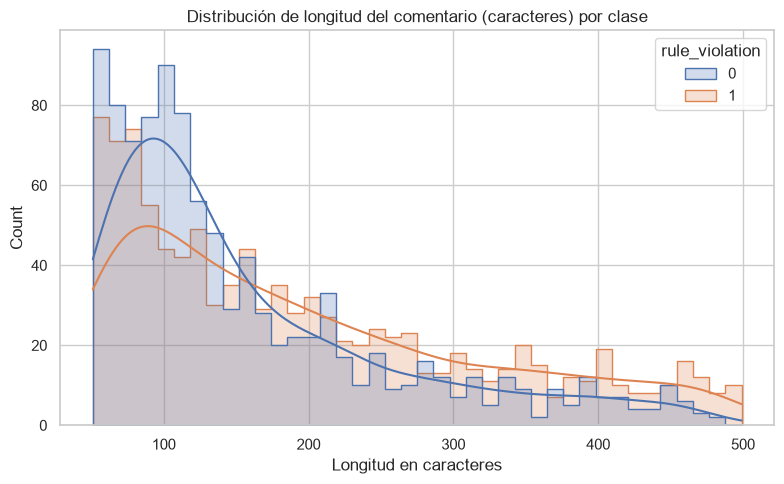

In [32]:
plt.figure(figsize=(8, 5))
sns.histplot(data=train, x="char_length", hue=TARGET, bins=40,
             kde=True, palette=["#4C72B0", "#DD8452"], element="step")
plt.title("Distribución de longitud del comentario (caracteres) por clase")
plt.xlabel("Longitud en caracteres")
plt.tight_layout()
savefig("01_histograma_longitud_texto.png")
plt.show()

### Longitud de texto por clase (boxplot)

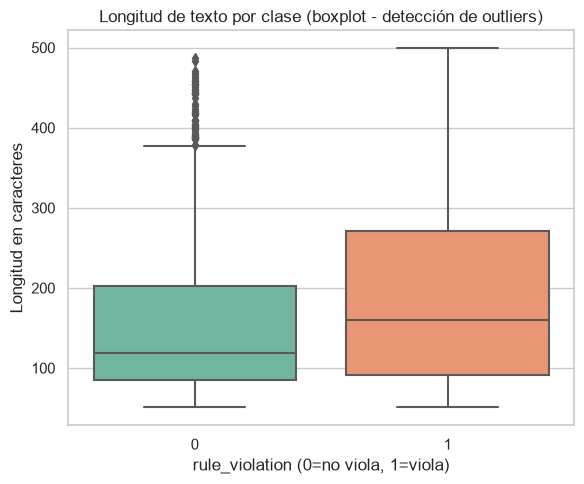

In [33]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=train, x=TARGET, y="char_length", palette="Set2")
plt.title("Longitud de texto por clase (boxplot - detección de outliers)")
plt.xlabel("rule_violation (0=no viola, 1=viola)")
plt.ylabel("Longitud en caracteres")
plt.tight_layout()
savefig("02_boxplot_longitud_por_clase.png")
plt.show()

### Frecuencia de cada regla evaluada

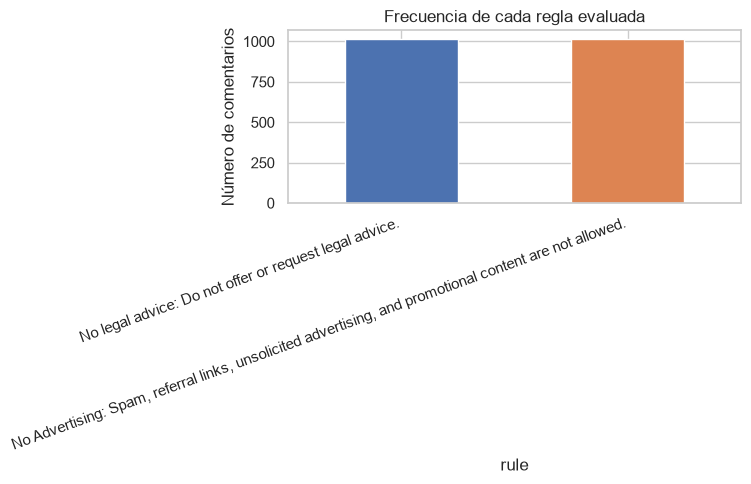

In [34]:
plt.figure(figsize=(7, 5))
train["rule"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Frecuencia de cada regla evaluada")
plt.ylabel("Número de comentarios")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
savefig("03_barras_frecuencia_regla.png")
plt.show()

### Top 15 subreddits más frecuentes

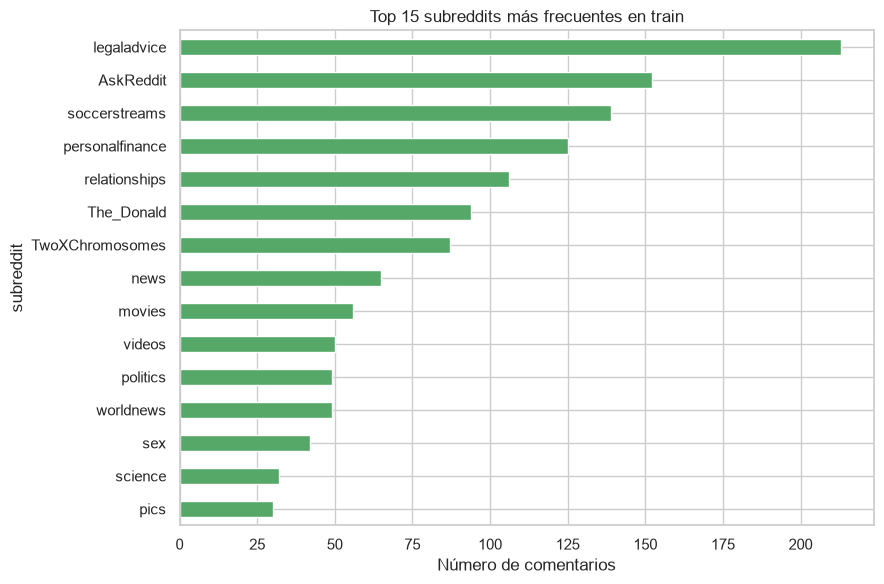

In [35]:
plt.figure(figsize=(9, 6))
train["subreddit"].value_counts().head(15).plot(kind="barh", color="#55A868")
plt.title("Top 15 subreddits más frecuentes en train")
plt.xlabel("Número de comentarios")
plt.gca().invert_yaxis()
plt.tight_layout()
savefig("04_barras_top_subreddits.png")
plt.show()

### Tasa de violación por subreddit (top 15)

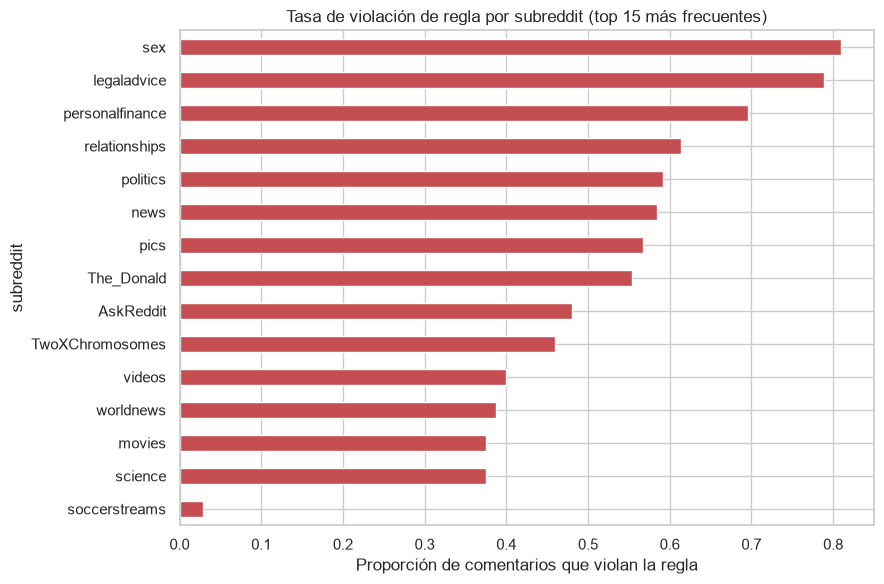

In [36]:
plt.figure(figsize=(9, 6))
rate_by_sub = (
    train[train["subreddit"].isin(top_subs)]
    .groupby("subreddit")[TARGET].mean()
    .sort_values(ascending=False)
)
rate_by_sub.plot(kind="barh", color="#C44E52")
plt.title("Tasa de violación de regla por subreddit (top 15 más frecuentes)")
plt.xlabel("Proporción de comentarios que violan la regla")
plt.gca().invert_yaxis()
plt.tight_layout()
savefig("05_tasa_violacion_por_subreddit.png")
plt.show()

### Tasa de violación por regla

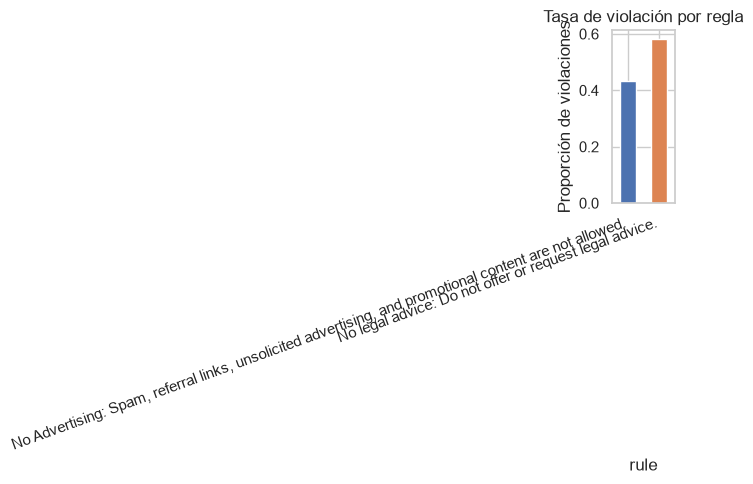

In [37]:
plt.figure(figsize=(6, 5))
train.groupby("rule")[TARGET].mean().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Tasa de violación por regla")
plt.ylabel("Proporción de violaciones")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
savefig("06_tasa_violacion_por_regla.png")
plt.show()

### Matriz de correlación entre variables numéricas y el target

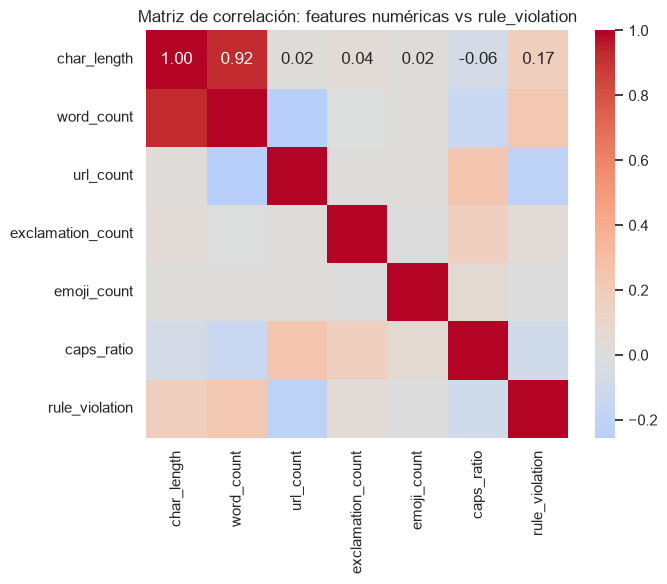

In [38]:
plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación: features numéricas vs rule_violation")
plt.tight_layout()
savefig("07_heatmap_correlacion.png")
plt.show()

### Proporción de indicadores binarios por clase

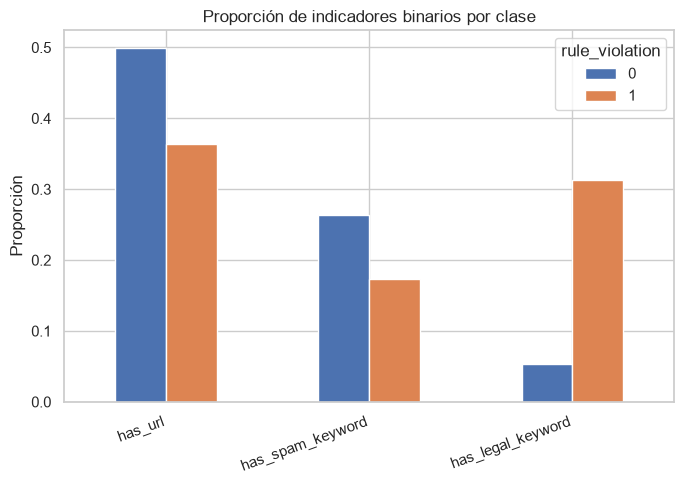

In [39]:
plt.figure(figsize=(7, 5))
flags = ["has_url", "has_spam_keyword", "has_legal_keyword"]
flag_means = train.groupby(TARGET)[flags].mean().T
flag_means.plot(kind="bar", ax=plt.gca())
plt.title("Proporción de indicadores binarios por clase")
plt.ylabel("Proporción")
plt.xticks(rotation=20, ha="right")
plt.legend(title="rule_violation")
plt.tight_layout()
savefig("08_indicadores_binarios_por_clase.png")
plt.show()

### Nube de palabras por clase

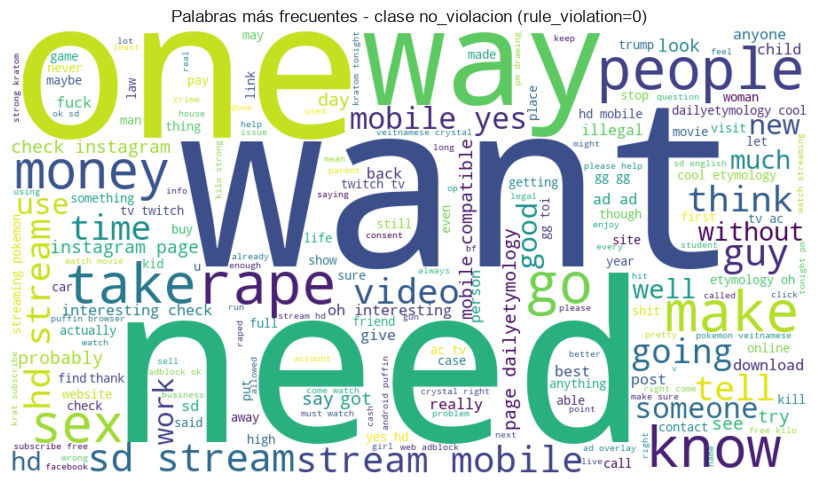

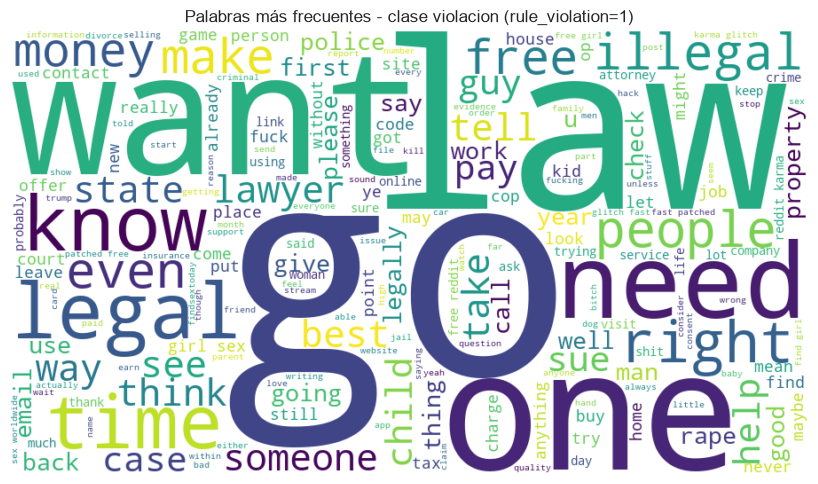

In [40]:
for label, name in [(0, "no_violacion"), (1, "violacion")]:
    text_blob = " ".join(train.loc[train[TARGET] == label, "body_lemmatized"])
    wc = WordCloud(width=900, height=500, background_color="white",
                   colormap="viridis").generate(text_blob)
    plt.figure(figsize=(9, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Palabras más frecuentes - clase {name} (rule_violation={label})")
    plt.tight_layout()
    savefig(f"09_wordcloud_{name}.png")
    plt.show()

### Cantidad de palabras vs cantidad de URLs por comentario

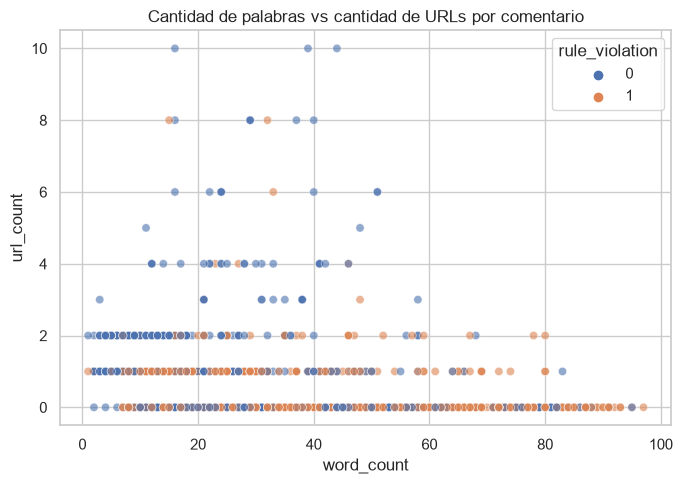

In [41]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=train, x="word_count", y="url_count", hue=TARGET,
                alpha=0.6, palette=["#4C72B0", "#DD8452"])
plt.title("Cantidad de palabras vs cantidad de URLs por comentario")
plt.tight_layout()
savefig("10_scatter_words_vs_urls.png")
plt.show()

## Guardado de los datasets limpios
Se guardan train y test ya limpios y con las variables derivadas, en la misma carpeta Datos de donde se extrajeron los originales.

In [42]:
train.to_csv("Datos/train_clean.csv", index=False)
test.to_csv("Datos/test_clean.csv", index=False)

print(f"train_clean.csv: {train.shape[0]} filas, {train.shape[1]} columnas")
print(f"test_clean.csv : {test.shape[0]} filas, {test.shape[1]} columnas")

train_clean.csv: 2029 filas, 21 columnas
test_clean.csv : 10 filas, 20 columnas


## Resumen de hallazgos
Estos números, junto con los gráficos generados, son el punto de partida para redactar la sección de hallazgos y conclusiones del informe.

In [43]:
violation_rate = train[TARGET].mean()
corr_url = train[["url_count", TARGET]].corr().iloc[0, 1]
corr_caps = train[["caps_ratio", TARGET]].corr().iloc[0, 1]

print(f"Tasa global de violación de regla en train: {violation_rate:.1%}")
print(f"Correlación entre url_count y rule_violation: {corr_url:.3f}")
print(f"Correlación entre caps_ratio y rule_violation: {corr_caps:.3f}")
print(f"Reglas únicas evaluadas: {train['rule'].nunique()}")
print(f"Subreddits únicos: {train['subreddit'].nunique()}")
print(f"Comentarios ('body') que se repiten con más de una regla: {n_dup_body_train}")

Tasa global de violación de regla en train: 50.8%
Correlación entre url_count y rule_violation: -0.212
Correlación entre caps_ratio y rule_violation: -0.095
Reglas únicas evaluadas: 2
Subreddits únicos: 100
Comentarios ('body') que se repiten con más de una regla: 57
